In [6]:
class Tensor:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float64)

    def __repr__(self):
        return str(self.data)

    def __add__(self, other):
        out = Tensor(self.data + other.data)
        return out

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data)
        return out

In [11]:
a = Tensor([[1,1],[1,1]])
b = Tensor([[2,2],[2,2]])
print(a + b)
print(a @ b)

[[3. 3.]
 [3. 3.]]
[[4. 4.]
 [4. 4.]]


In [12]:
x = Tensor([[1, 2]])
w = Tensor([[2, 1], [1, 2]])
b = Tensor([[1, 1]])

y = x @ w + b
y

[[5. 6.]]

In [22]:
class Tensor:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self.back = lambda: None

    def __repr__(self):
        return str(self.data)

    def __add__(self, other):
        out = Tensor(self.data + other.data)
        def _back():
            self.grad  += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)
        out._back = _back
        return out

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data)
        def _back():
            self.grad  += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        out._back = _back
        return out

In [26]:
def _unbroadcast(grad, shape):
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for i, (g, s) in enumerate(zip(grad.shape, shape)):
        if s == 1 and g > 1:
            grad = grad.sum(axis=i, keepdims=True)
    return grad

In [23]:
x = Tensor([[3,3]])
w = Tensor([[2,2],[2,2]])

y = x @ w

# Set gradient to 1s as y is the output.
y.grad = np.ones_like(y.data)

y._back()

w.grad

array([[3., 3.],
       [3., 3.]])

In [24]:
class Tensor:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self._back = lambda: None
        self._children = []

    def __repr__(self):
        return str(self.data)

    def __add__(self, other):
        out = Tensor(self.data + other.data)
        def _back():
            self.grad  += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)
        out._back = _back
        out._children = [self, other]
        return out

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data)
        def _back():
            self.grad  += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        out._back = _back
        out._children = [self, other]
        return out

    def _unbroadcast(grad, shape):
        while grad.ndim > len(shape):
            grad = grad.sum(axis=0)
        for i, (g, s) in enumerate(zip(grad.shape, shape)):
            if s == 1 and g > 1:
                grad = grad.sum(axis=i, keepdims=True)
        return grad

    def _topo_sort(self):
        topo = []
        def visit(v):
            if v not in topo:
                for child in v._children:
                    visit(child)
                topo.append(v)
        visit(self)
        return topo

    def backward(self):
        self.grad = np.ones_like(self.data)
        for v in reversed(self._topo_sort()):
            v._back()

In [25]:
x = Tensor([[3, 3]])
w = Tensor([[2, 2], [2, 2]])
b = Tensor([[4, 4]])

y = x @ w + b
y

y.backward()

print(w.grad)
print(b.grad)

[[3. 3.]
 [3. 3.]]
[[1. 1.]]


In [45]:
import numpy as np

class Tensor:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self._back = lambda: None
        self._children = []

    def __repr__(self):
        return str(self.data)

    def __add__(self, other):
        out = Tensor(self.data + other.data)
        def _back():
            self.grad  += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)
        out._back = _back
        out._children = [self, other]
        return out

    def __mul__(self, other):
        out = Tensor(self.data * other.data)
        def _back():
            self.grad  += _unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += _unbroadcast(self.data  * out.grad, other.data.shape)
        out._back = _back
        out._children = [self, other]
        return out

    def __sub__(self, other):
        return self + (Tensor([-1]) * other)

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data)
        def _back():
            self.grad  += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        out._back = _back
        out._children = [self, other]
        return out

    def relu(self):
        out = Tensor(np.maximum(0, self.data))
        def _back():
            self.grad += (out.data > 0) * out.grad
        out._back = _back
        out._children = [self]
        return out

    # def mean(self):
    #     n = self.data.size
    #     out = Tensor(self.data.mean())
    #     def _back():
    #         grad = out.grad * (1/n)
    #         self.grad += np.broadcast_to(grad, self.data.shape)
    #     out._back = _back
    #     return out

    def _topo_sort(self):
        topo = []
        def visit(v):
            if v not in topo:
                for child in v._children:
                    visit(child)
                topo.append(v)
        visit(self)
        return topo

    def backward(self):
        self.grad = np.ones_like(self.data)
        for v in reversed(self._topo_sort()):
            v._back()

    

In [28]:
class Linear:
    def __init__(self, in_features: int, out_features: int):
        self.W = Tensor(np.random.randn(in_features, out_features))
        self.b = Tensor(np.zeros((1, out_features)))

    def __call__(self, x: Tensor) -> Tensor:
        return x @ self.W + self.b

    def parameters(self) -> list:
        return [self.W, self.b]

In [29]:
class ReLU:
    def __call__(self, x): return x.relu()

In [30]:
class Sequential:
    def __init__(self, *layers):
        self.layers = layers

    def __call__(self, x: Tensor) -> Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self) -> list:
        params = []
        for layer in self.layers:
            if hasattr(layer, 'parameters'):
                params.extend(layer.parameters())
        return params

In [77]:
# XOR Dataset
X = Tensor([[0, 0],
            [0, 1],
            [1, 0],
            [1, 1]])
Y = Tensor([[0], [1], [1], [0]]) 


model = Sequential(
    Linear(2, 4),
    ReLU(),
    Linear(4, 1),
)

mse_log = []

for epoch in range(1, 500):
        mses = np.array([])
        for x, y in zip(X.data, Y.data):
            inp    = Tensor(x[None])
            target = Tensor([[y]])
            pred   = model(inp)
            mse   = ((pred - target) * (pred - target))

            # Clear gradients from previous epoch.
            model_params = model.parameters()
            for p in model_params:
                p.grad = np.zeros_like(p.data)

            # Calculate new gradients.
            mse.backward()

            # Update weights.
            for p in model_params:
                p.data -= 0.05 * p.grad

            mses = np.append(mses, mse.data)


        mse_mean = mses.mean()
        mse_log.append(mse_mean)
    
        if epoch % 50 == 0:
            print(f"epoch {epoch:4d} | mse {mse_mean:.4f}")


epoch   50 | mse 0.0055
epoch  100 | mse 0.0000
epoch  150 | mse 0.0000
epoch  200 | mse 0.0000
epoch  250 | mse 0.0000
epoch  300 | mse 0.0000
epoch  350 | mse 0.0000
epoch  400 | mse 0.0000
epoch  450 | mse 0.0000


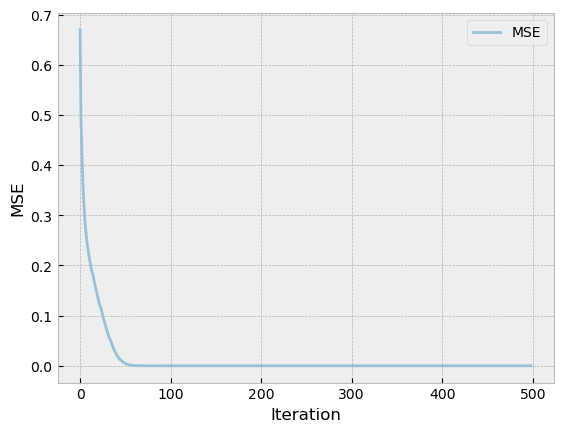

In [83]:
import matplotlib.pyplot as plt

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

plt.plot(mse_log, c=colors[1], label="MSE")
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.savefig("plot.png")